In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Constante
HBAR_SI    = 1.054_571_817e-34   # J·s
QE         = 1.602_176_634e-19   # C
ME_SI      = 9.109_383_7015e-31  # kg
UM_TO_M    = 1e-6                # µm -> m
PS_TO_S    = 1e-12               # ps -> s
HBAR_meVps = (HBAR_SI / QE) * 1e3 / PS_TO_S   # ħ ≈ 0.658211951 meV·ps

#Importation des données dGPE
data = np.load("simulation_dGPE.npz", allow_pickle=True)

x = data["x"]
k_um = data["k_um"]
t_list = data["t_list"]
psi_list = data["psi_list"]
nR_list = data["nR_list"]
m_rel = data["m_rel"]

def phase_centre(psi):
    #Phase dépliée SANS drift global, enlève la rotation uniforme de phase
    phi = np.unwrap(np.angle(psi))
    return phi - phi.mean()

phi_list = [phase_centre(psi) for psi in psi_list]

[Fit spatial] α = 0.480320 pour Δx ∈ [12.0, 35.0]


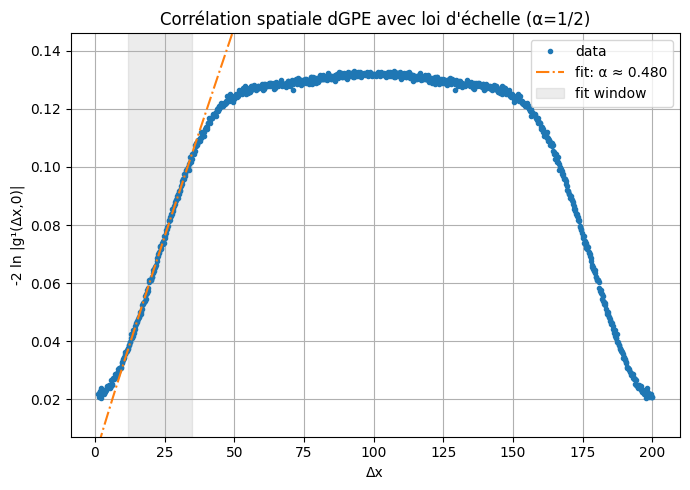

In [12]:
### Fonction de corrélations et exposant universels ###

def g1_spatial(phi_t):
    # g1(Δx,0)
    phi = np.asarray(phi_t)
    N = len(phi)
    g1 = np.zeros(N, dtype=complex)

    for dx in range(N):
        dphi = np.roll(phi, -dx) - phi
        g1[dx] = np.mean(np.exp(1j * dphi))

    return g1

def plot_g1_spatial(x, phi, xmin=None, xmax=None, shift_y=0, fit=False, fit_xmin=None, fit_xmax=None):
    #Trace la fonction de corrélation spatiale, avec courbe d'alpha théorique (et fit optionnel)
    g1 = np.abs(g1_spatial(phi))
    dx = x - x[0]

    mask = (dx > 0) & (g1 < 1) & (g1 > 1e-6)
    if xmin is not None:
        mask &= (dx >= xmin)
    if xmax is not None:
        mask &= (dx <= xmax)

    dx_plot = dx[mask]
    g1_plot = g1[mask]
    Y = -2 * np.log(g1_plot)

    # Exposant KPZ spatial 2α = 1
    exposant = 1.0

    # Normalisation
    X0 = dx_plot.mean()
    Y0 = Y.mean()

    X_kpz = np.linspace(dx_plot.min(), dx_plot.max(), 200)
    Y_kpz = Y0 * (X_kpz / X0)**exposant + shift_y

    plt.figure(figsize=(7, 5))
    plt.plot(dx_plot, Y, ".", label="data")
    # Fit optionnel
    if fit:
        mask_fit = np.ones_like(dx_plot, dtype=bool)
        if fit_xmin is not None:
            mask_fit &= (dx_plot >= fit_xmin)
        if fit_xmax is not None:
            mask_fit &= (dx_plot <= fit_xmax)

        X_fit = dx_plot[mask_fit]
        Y_fit = Y[mask_fit]

        if len(X_fit) >= 2:
            logX = np.log(X_fit)
            logY = np.log(Y_fit)
            slope, intercept = np.polyfit(logX, logY, 1)
            exponent_fit = slope
            
            Y_fit_curve = np.exp(intercept) * (X_kpz**exponent_fit)

            plt.plot(X_kpz, Y_fit_curve, "-.",
                    label=fr"fit: α ≈ {exponent_fit/2:.3f}")
            plt.axvspan(fit_xmin, fit_xmax, color="gray", alpha=0.15, label="fit window")
            print(f"[Fit spatial] α = {exponent_fit/2:.6f} pour Δx ∈ [{fit_xmin:.1f}, {fit_xmax:.1f}]")
    #plt.plot(X_kpz, Y_kpz, "--", label="KPZ α = 1/2")
    plt.xlabel("Δx")
    plt.ylabel("-2 ln |g¹(Δx,0)|")
    plt.title("Corrélation spatiale dGPE avec loi d'échelle (α=1/2)")
    plt.grid()
    plt.ylim(Y.min()-0.1*Y.max(), Y.max()+0.1*Y.max())
    plt.legend()
    plt.tight_layout()
    plt.show()


t_index_alpha = 0    # temps choisi
phi_t = phi_list[t_index_alpha]

plot_g1_spatial(x, phi_t, xmin=1, xmax=200, shift_y=0.02, fit=True, fit_xmin=12, fit_xmax=35)


[Fit temporel] β = 0.420686 pour Δt ∈ [704.0, 1500.0]


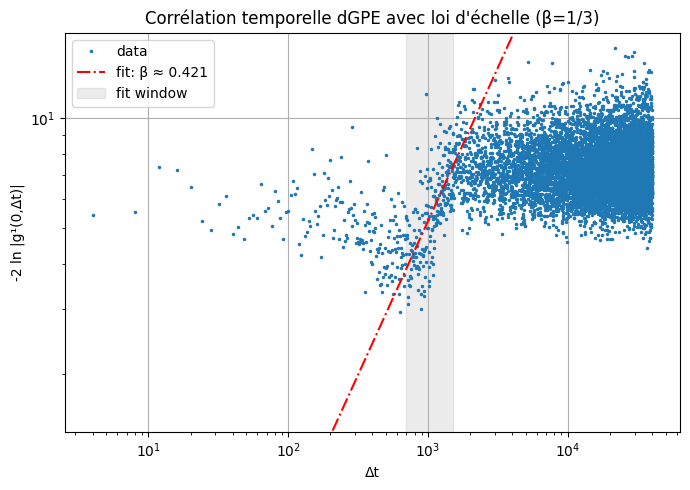

In [7]:
def g1_temporel(phi_list, t_index_ref):
    #g1(0,Δt)
    phi_list = [np.asarray(phi) for phi in phi_list]
    phi_ref = phi_list[t_index_ref]

    g1 = []
    for phi in phi_list[t_index_ref:]:
        dphi = phi - phi_ref
        g1.append(np.mean(np.exp(1j * dphi)))

    return np.array(g1, dtype=complex)


def plot_g1_temporel(t_list, phi_list, t_index_ref, tmin=None, tmax=None, shift_y=0.0, fit=False, fit_tmin=None, fit_tmax=None):
    #Trace la fonction de corrélation temporel, avec courbe de beta théorique (et fit optionnel)
    g1 = np.abs(g1_temporel(phi_list, t_index_ref))
    dt = np.array(t_list[t_index_ref:]) - t_list[t_index_ref]

    mask = (dt > 0) & (g1 < 1) & (g1 > 1e-6)
    if tmin is not None:
        mask &= (dt >= tmin)
    if tmax is not None:
        mask &= (dt <= tmax)

    dt_plot = dt[mask]
    g1_plot = g1[mask]
    Y = -2 * np.log(g1_plot)

    # Exposant temporel KPZ 2β = 2/3
    exposant = 2/3

    X0 = dt_plot.mean()
    Y0 = Y.mean()

    X_kpz = np.linspace(dt_plot.min(), dt_plot.max(), 200)
    Y_kpz = Y0 * (X_kpz / X0)**exposant + shift_y

    plt.figure(figsize=(7, 5))
    plt.loglog(dt_plot, Y, ".", label="data", markersize=3, alpha=1)
    if fit:
        mask_fit = np.ones_like(dt_plot, dtype=bool)
        if fit_tmin is not None:
            mask_fit &= (dt_plot >= fit_tmin)
        if fit_tmax is not None:
            mask_fit &= (dt_plot <= fit_tmax)

        X_fit = dt_plot[mask_fit]
        Y_fit = Y[mask_fit]

        if len(X_fit) >= 2:
            logX = np.log(X_fit)
            logY = np.log(Y_fit)
            slope, intercept = np.polyfit(logX, logY, 1)
            exponent_fit = slope
            beta_fit = exponent_fit / 2.0

            Y_fit_curve = np.exp(intercept) * (X_kpz**exponent_fit)

            plt.loglog(X_kpz, Y_fit_curve, "r-.",
                    label=fr"fit: β ≈ {exponent_fit/2:.3f}")
            plt.axvspan(fit_tmin, fit_tmax, color="gray", alpha=0.15, label="fit window")
            fit_dt_min = X_fit.min()
            fit_dt_max = X_fit.max()
            print(f"[Fit temporel] β = {beta_fit:.6f} pour Δt ∈ [{fit_dt_min:.1f}, {fit_dt_max:.1f}]")
    #plt.loglog(X_kpz, Y_kpz, "--", label="KPZ β = 1/3")
    plt.ylim(dt_plot.min(), dt_plot.max())
    plt.xlabel("Δt")
    plt.ylabel("-2 ln |g¹(0,Δt)|")
    plt.title("Corrélation temporelle dGPE avec loi d'échelle (β=1/3)")
    plt.grid()
    plt.ylim(Y.min()-0.1*Y.max(), Y.max()+0.1*Y.max())
    plt.legend()
    plt.tight_layout()
    plt.show()


t_index_ref = 0   # temps de référence
plot_g1_temporel(t_list, phi_list, t_index_ref, tmin=1, tmax=40000, shift_y=0.6, fit=True, fit_tmin=700, fit_tmax=1500 )
